# Libraries Import

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.cluster import KMeans

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, f1_score

#Data Sampling
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

# EDA 1

In [3]:

df = pd.read_csv("/content/Mall_Customers.csv")
pd.set_option('display.max_columns', None)

df = df.drop(columns = "CustomerID")
print(df.columns)
print(df.head(10))


le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"]) #Male-> 1, Female-> 0
print(df.head(10))

df_original = df.copy() #STored a copy

scalers = []
numer = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for i in range(3):
  st = StandardScaler()
  df[numer[i]] = st.fit_transform(df[[numer[i]]])
  scalers.append(st)
print(df.head(10))

with open("processed.csv", "wb") as f:
  pickle.dump(df, f)

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40
5  Female   22                  17                      76
6  Female   35                  18                       6
7  Female   23                  18                      94
8    Male   64                  19                       3
9  Female   30                  19                      72
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23            

# Choosing number of clusters

K=2: 0.3032
K=3: 0.3120
K=4: 0.3504
K=5: 0.3498
K=6: 0.3565
K=7: 0.3316
K=8: 0.3362
K=9: 0.3118
K=10: 0.3087


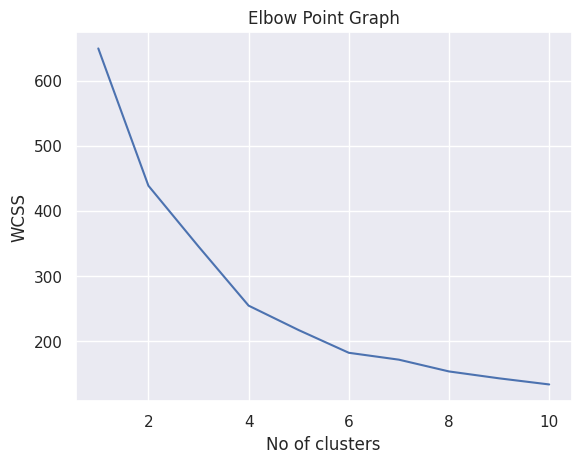

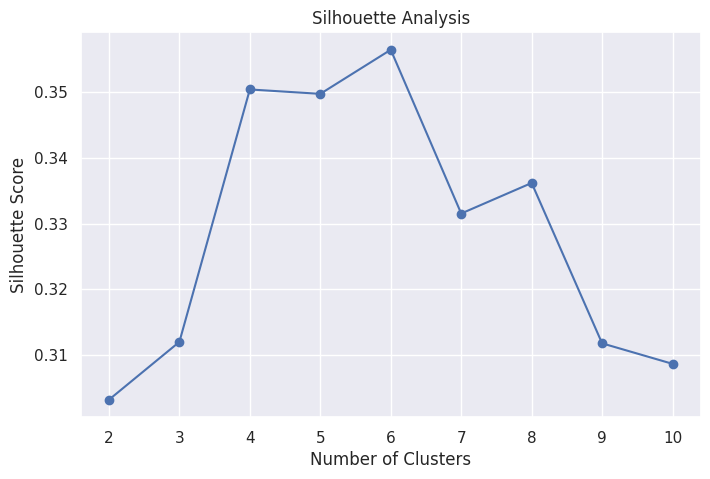

In [4]:
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto') #Watch Video
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)


sns.set()
plt.plot(range(1,11), wcss)
plt.title("Elbow Point Graph")
plt.xlabel("No of clusters")
plt.ylabel("WCSS")


from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df)
    scores.append(silhouette_score(df, labels))
    print(f"K={k}: {silhouette_score(df, labels):.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

#Choosing the Model (n = 4)

In [ ]:
kmeansF = KMeans(n_clusters=4, random_state=42, n_init='auto') #Watch Video
kmeansF.fit(df)

df_original["Cluster"] = kmeansF.labels_
print(df_original["Cluster"].value_counts())
print(df_original.tail(10))

print("\nCluster Profiles (Averages):")
print(df_original.groupby("Cluster").mean())

Cluster
0    64
2    57
3    40
1    39
Name: count, dtype: int64
     Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
190       0   34                 103                      23        1
191       0   32                 103                      69        3
192       1   33                 113                       8        1
193       0   38                 113                      91        3
194       0   47                 120                      16        1
195       0   35                 120                      79        3
196       0   45                 126                      28        1
197       1   32                 126                      74        3
198       1   32                 137                      18        1
199       1   30                 137                      83        3

Cluster Profiles (Averages):
           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                      

# Training with Only Annual Income & Spending Score

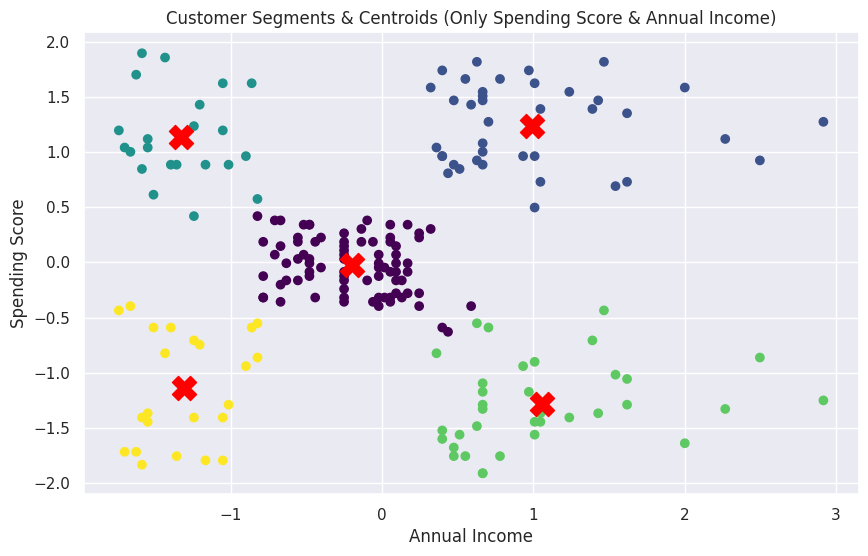

In [ ]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]
kmeans2 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init='auto'
)

clusters = kmeans2.fit_predict(X)

centroids = kmeans2.cluster_centers_
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters,
    cmap='viridis'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments & Centroids (Only Spending Score & Annual Income)")

plt.show()

#PCA Visualization

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Cluster'],
      dtype='object')


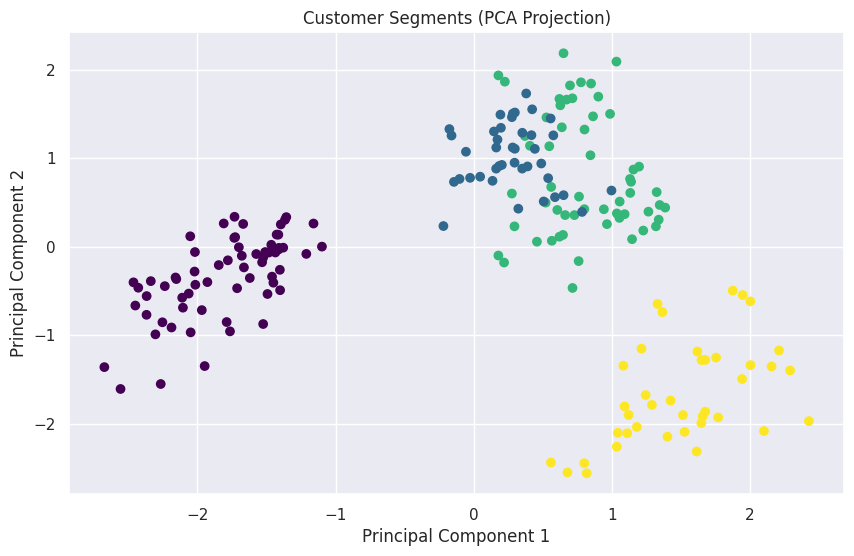

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
print(df.columns)
X_pca = pca.fit_transform(df)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Customer Segments (PCA Projection)")

plt.show()

# PCA with centroids

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


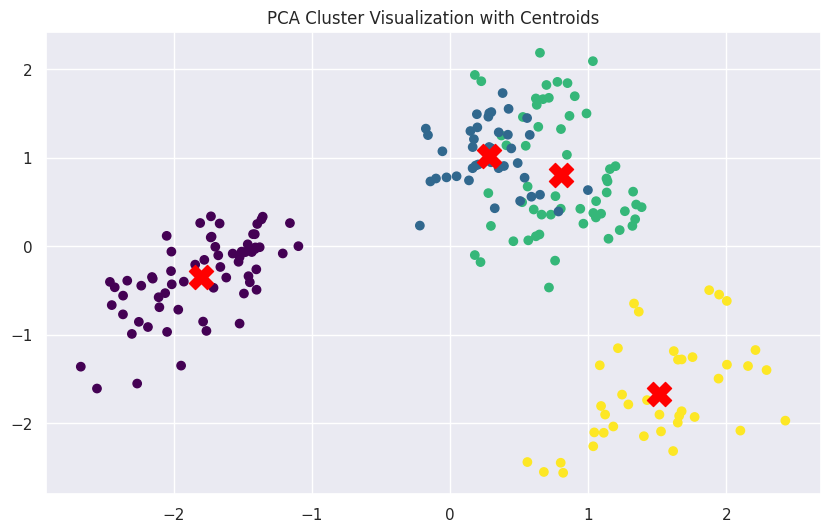

In [ ]:
centroids_pca = pca.transform(kmeansF.cluster_centers_)
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap='viridis'
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c='red',
    s=300,
    marker='X'
)

plt.title("PCA Cluster Visualization with Centroids")

plt.show()